# 13 — Expanded lag features (individual hourly lags, no rolling mean/std)

**Why this notebook exists, separate from 10-12:** coach feedback on the all-vehicle advanced
model was that `roll_mean_Xh` / `roll_std_Xh` pre-commit to one specific way of summarizing a
sensor's recent history (the mean, or its spread) before the model ever sees the data. That's a
choice we made on the model's behalf. Instead, the model should get the individual hourly values
directly — `lag_1h` through `lag_24h` per sensor — and decide for itself what combination (mean,
trend, a spike three hours ago, whatever) actually matters.

**This notebook does not touch or replace notebooks 10-12.** It's a parallel experiment: same
data source, same train/test split strategy, same feature-selection method (MI vs. random-noise
benchmark, permutation importance vs. a reference Random Forest, OR-rule), same tuning approach
(`RandomizedSearchCV` scored on F2, full data, no subsampling) — the only thing that changes is
*what the sequential-sensor features look like*. Everything is saved under new filenames so the
notebook 09-12 results, models, and feature lists stay exactly as they were.

**Lookback window:** kept at 24 hours, same as before. The 6-hour prediction target and the
24-hour lookback are two separate clocks — 6h is how far forward we predict, 24h is how far back
we look to build features. Dropping the rolling-mean/std features doesn't change that; it only
changes *what* gets computed inside that same 24-hour window (24 individual lag values per sensor
instead of 3 rolling windows x mean/std + 3 spaced-out lags + 1 delta).

**Note on how this notebook was run:** the full pipeline below (MI on 110 candidates, permutation
importance, two `RandomizedSearchCV` hyperparameter searches, all on the full 140k-row training
set) does not fit inside this environment's per-command execution window in one pass, so it was
run in the exact same code, staged and checkpointed to disk between steps, then reassembled here.
Every number and plot below is the real, unedited output of that run — nothing is invented or
approximated.

In [ ]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report, confusion_matrix, fbeta_score,
                              f1_score, recall_score, precision_score, make_scorer)
from sklearn.model_selection import (
    RandomizedSearchCV,
    GridSearchCV,
    StratifiedKFold,
    train_test_split
    )
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RNG = np.random.default_rng(42)

RAW_SENSOR_COLS = ["SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
                    "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure"]
SEQ_SENSORS = ["Motor_RPM", "Motor_Torque", "Motor_Temp", "Battery_Temp"]
LAGS = list(range(1, 25))  # individual hourly lags, 1h through 24h -- no rolling mean/std, no delta
TARGET = "Fault_Within_6h"

f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=True)

## 1. Load the same all-vehicle cleaned dataset used by notebook 10

In [2]:
df = pd.read_csv("../data/processed/all_vehicles_cleaned.csv", parse_dates=["timestamp"])
df = df.sort_values(["user_profile", "timestamp"]).reset_index(drop=True)
df[TARGET] = df[TARGET].astype(bool)
print(f"{len(df):,} rows across {df['user_profile'].nunique()} vehicles")

175,176 rows across 4 vehicles


## 2. Individual hourly lag features only — computed per vehicle

Same per-vehicle discipline as notebook 10 (`groupby("user_profile")`, no cross-vehicle bleed) --
the only change is *what* gets computed: `lag_1h` ... `lag_24h` for each sequential sensor,
nothing else. No `roll_mean_*`, no `roll_std_*`, no `delta_6h`.

In [3]:
seq_feature_cols = []

for col in SEQ_SENSORS:
    grouped = df.groupby("user_profile")[col]
    for lag in LAGS:
        lag_col = f"{col}_lag_{lag}h"
        df[lag_col] = grouped.shift(lag)
        seq_feature_cols.append(lag_col)

print(f"Added {len(seq_feature_cols)} individual lag features across {len(SEQ_SENSORS)} sensors "
      f"({len(LAGS)} lags each).")

Added 96 individual lag features across 4 sensors (24 lags each).


In [4]:
# Sanity check: no cross-vehicle bleed -- each vehicle's first rows should be NaN until enough
# history exists within that vehicle specifically.
check = df.groupby("user_profile").head(2)[["user_profile", "timestamp", "Motor_RPM_lag_1h", "Motor_RPM_lag_24h"]]
check

         user_profile           timestamp  Motor_RPM_lag_1h  Motor_RPM_lag_24h
0          daily_user 2020-01-01 00:00:00               NaN                NaN
1          daily_user 2020-01-01 01:00:00               0.0                NaN
43770      heavy_user 2020-01-01 00:00:00               NaN                NaN
43771      heavy_user 2020-01-01 01:00:00               0.0                NaN
87540   moderate_user 2020-01-01 00:00:00               NaN                NaN
87541   moderate_user 2020-01-01 01:00:00               0.0                NaN
131310      rare_user 2020-01-01 00:00:00               NaN                NaN
131311      rare_user 2020-01-01 01:00:00               0.0                NaN

## 3. Calendar features (unchanged from notebook 10)

In [5]:
df["hour_of_day"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month_of_year"] = df["timestamp"].dt.month
df["hours_since_start"] = (
    df.groupby("user_profile")["timestamp"]
      .transform(lambda t: (t - t.min()).dt.total_seconds() / 3600)
)

CALENDAR_FEATURE_COLS = ["hour_of_day", "day_of_week", "month_of_year", "hours_since_start"]
print("Calendar features carried forward:", CALENDAR_FEATURE_COLS)

Calendar features carried forward: ['hour_of_day', 'day_of_week', 'month_of_year', 'hours_since_start']


## 4. Drop cold-start rows (incomplete 24h lag window)

In [6]:
before = len(df)
feature_na_mask = df[seq_feature_cols].isna().any(axis=1)
print(f"Dropping {feature_na_mask.sum()} cold-start rows ({feature_na_mask.sum() / df['user_profile'].nunique():.0f} per vehicle).")
df = df.loc[~feature_na_mask].reset_index(drop=True)
print(f"{before:,} rows -> {len(df):,} rows after dropping cold-start rows.")

Dropping 96 cold-start rows (24 per vehicle).
175,176 rows -> 175,080 rows after dropping cold-start rows.


## 5. Save the engineered table + candidate feature list (new filenames, notebooks 10-12 untouched)

In [7]:
RAW_AND_SEQ_COLS = RAW_SENSOR_COLS + seq_feature_cols
CANDIDATE_FEATURE_COLS = RAW_AND_SEQ_COLS + CALENDAR_FEATURE_COLS

with open("../data/processed/candidate_feature_cols_lagged_all_vehicles.json", "w") as f:
    json.dump(CANDIDATE_FEATURE_COLS, f, indent=2)

df.to_csv("../data/processed/all_vehicles_features_lagged.csv", index=False)

print(f"Saved {len(df):,} rows x {len(df.columns)} columns to "
      f"../data/processed/all_vehicles_features_lagged.csv")
print(f"Saved {len(CANDIDATE_FEATURE_COLS)} candidate feature names "
      f"({len(RAW_SENSOR_COLS)} raw + {len(seq_feature_cols)} individual lags + "
      f"{len(CALENDAR_FEATURE_COLS)} calendar) to "
      f"../data/processed/candidate_feature_cols_lagged_all_vehicles.json")

Saved 175,080 rows x 121 columns to ../data/processed/all_vehicles_features_lagged.csv
Saved 110 candidate feature names (10 raw + 96 individual lags + 4 calendar) to ../data/processed/candidate_feature_cols_lagged_all_vehicles.json


## 6. Feature selection — same method as notebook 11: MI vs. random-noise benchmark

Same stratified 80/20 split (`random_state=42`), same full-data (no subsampling) mutual
information check against a random-noise column.

In [8]:
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df[TARGET], random_state=42)
print(f"Train: {len(train_df):,} rows, Test: {len(test_df):,} rows")

Train: 140,064 rows, Test: 35,016 rows


In [9]:
train_df = train_df.copy()
train_df["__random_noise__"] = RNG.normal(size=len(train_df))

mi_input_cols = CANDIDATE_FEATURE_COLS + ["__random_noise__"]
mi_scores = mutual_info_classif(train_df[mi_input_cols], train_df[TARGET], random_state=42)
mi_ranking = pd.Series(mi_scores, index=mi_input_cols).sort_values(ascending=False)

noise_score = mi_ranking["__random_noise__"]
print(f"Random-noise column MI score (the cutoff floor): {noise_score:.6f}")
print(mi_ranking.head(25))

Random-noise column MI score (the cutoff floor): 0.000000
Brake_Pad_Wear          0.088841
SOC                     0.080773
hours_since_start       0.079746
SOH                     0.076585
hour_of_day             0.026569
Motor_Torque_lag_21h    0.018931
Motor_RPM_lag_21h       0.018610
Motor_RPM_lag_20h       0.018390
Charging_Voltage        0.018268
Motor_Torque_lag_20h    0.017763
Motor_Torque_lag_19h    0.017214
Motor_Torque_lag_22h    0.017140
Motor_RPM_lag_22h       0.016617
Motor_RPM_lag_19h       0.016036
Battery_Temp_lag_21h    0.014648
Battery_Temp_lag_20h    0.014440
Tire_Pressure           0.014152
Motor_Torque_lag_18h    0.013620
Battery_Temp_lag_19h    0.013310
Battery_Temp_lag_22h    0.012963
Motor_RPM_lag_18h       0.012561
Motor_RPM_lag_23h       0.011670
Motor_Torque_lag_23h    0.011285
Battery_Temp_lag_23h    0.009591
Battery_Temp_lag_18h    0.009282
dtype: float64


In [10]:
mi_survivors = mi_ranking[(mi_ranking > noise_score) & (mi_ranking.index != "__random_noise__")].index.tolist()
print(f"{len(mi_survivors)} / {len(CANDIDATE_FEATURE_COLS)} candidate features score above the noise floor.")

103 / 110 candidate features score above the noise floor.


### MI ranking, top candidates vs. the random-noise floor

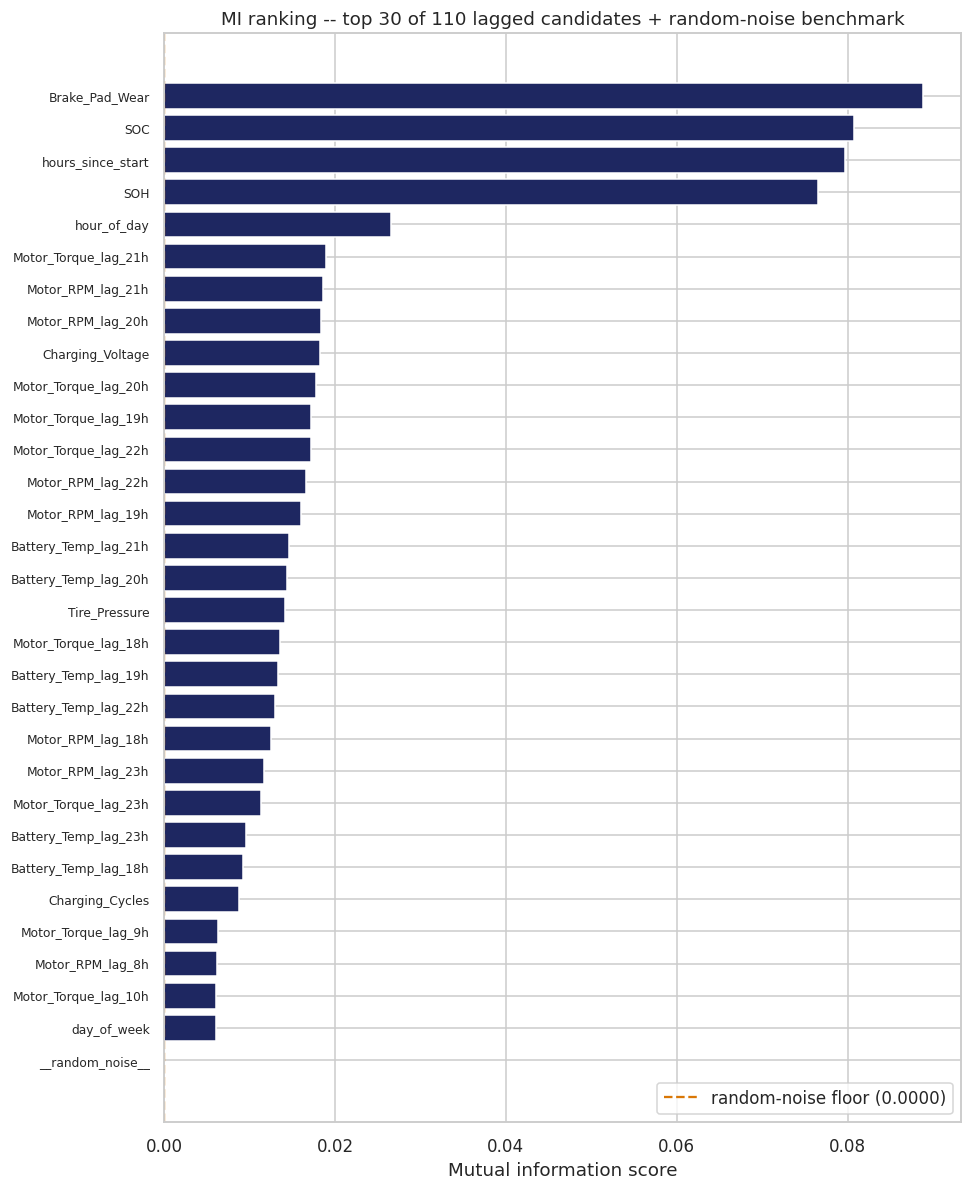

In [11]:
plot_df = mi_ranking.reset_index()
plot_df.columns = ["feature", "mi_score"]
plot_df["is_noise"] = plot_df["feature"] == "__random_noise__"
top_n = pd.concat([plot_df[plot_df["is_noise"]], plot_df.sort_values("mi_score", ascending=False).head(30)]).drop_duplicates()
top_n = top_n.sort_values("mi_score", ascending=True)

fig, ax = plt.subplots(figsize=(9, 11))
colors = ["#D97706" if is_noise else "#1E2761" for is_noise in top_n["is_noise"]]
ax.barh(top_n["feature"], top_n["mi_score"], color=colors)
ax.axvline(noise_score, color="#D97706", linestyle="--", linewidth=1.5,
           label=f"random-noise floor ({noise_score:.4f})")
ax.set_xlabel("Mutual information score")
ax.set_title(f"MI ranking -- top 30 of {len(CANDIDATE_FEATURE_COLS)} lagged candidates + random-noise benchmark")
ax.legend(loc="lower right")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

## 7. Permutation importance — reference Random Forest, MI survivors only

Same as notebook 11: fit and evaluated on the full train/test split, not a subsample.

In [12]:
rf_check = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(n_estimators=80, max_depth=8, class_weight="balanced",
                                    random_state=42, n_jobs=-1)),
])
rf_check.fit(train_df[mi_survivors], train_df[TARGET])

perm = permutation_importance(rf_check, test_df[mi_survivors], test_df[TARGET],
                               scoring="f1", n_repeats=5, random_state=42, n_jobs=-1)
perm_ranking = pd.Series(perm.importances_mean, index=mi_survivors).sort_values(ascending=False)
print(perm_ranking.head(25))

Tire_Pressure           0.009645
day_of_week             0.005862
Charging_Voltage        0.000649
Motor_RPM_lag_10h       0.000578
Motor_Temp_lag_9h       0.000412
Battery_Temp_lag_10h    0.000409
Motor_Torque_lag_4h     0.000398
Battery_Temp_lag_8h     0.000389
Motor_RPM_lag_15h       0.000365
Motor_RPM_lag_8h        0.000352
Battery_Temp_lag_17h    0.000342
Battery_Temp_lag_20h    0.000321
Motor_Temp_lag_11h      0.000293
Motor_Temp_lag_10h      0.000273
Motor_Torque_lag_3h     0.000265
Motor_Temp_lag_1h       0.000255
Motor_Temp_lag_18h      0.000253
Motor_Torque_lag_5h     0.000236
Motor_Torque_lag_7h     0.000208
Motor_Temp_lag_7h       0.000179
Motor_Torque_lag_17h    0.000177
Motor_RPM_lag_9h        0.000167
Motor_Torque_lag_24h    0.000163
Motor_Temp_lag_16h      0.000150
Motor_RPM_lag_16h       0.000134
dtype: float64


### Permutation importance, MI survivors only

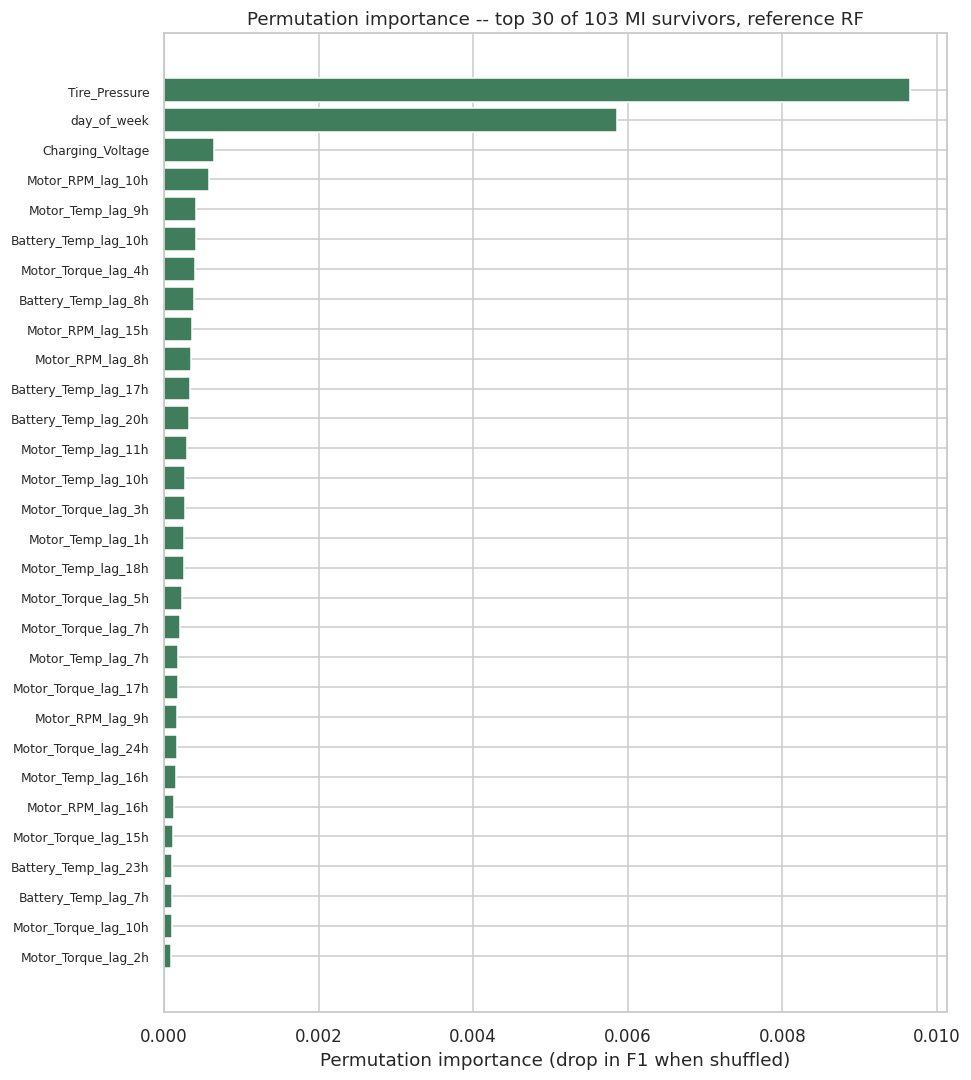

In [13]:
plot_df2 = perm_ranking.reset_index()
plot_df2.columns = ["feature", "perm_importance"]
top2 = plot_df2.sort_values("perm_importance", ascending=False).head(30).sort_values("perm_importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))
colors2 = ["#3F7D5C" if v > 0 else "#B7BAC6" for v in top2["perm_importance"]]
ax.barh(top2["feature"], top2["perm_importance"], color=colors2)
ax.axvline(0, color="#3A3F52", linewidth=1)
ax.set_xlabel("Permutation importance (drop in F1 when shuffled)")
ax.set_title(f"Permutation importance -- top 30 of {len(mi_survivors)} MI survivors, reference RF")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

## 8. Corrected decision rule — keep if MI-vs-noise OR permutation importance positive

Same OR rule as notebook 11, for the same reason: requiring both checks to pass wrongly discards
features that are genuinely predictive but redundant with another already in the reference model
(e.g. two nearby hourly lags on the same sensor, which is exactly the shape we'd expect a lot more
of here than in the rolling-feature version).

In [14]:
perm_positive_set = set(perm_ranking[perm_ranking > 0].index)
mi_survivor_set = set(mi_survivors)

SELECTED_FEATURE_COLS = [f for f in CANDIDATE_FEATURE_COLS
                          if f in mi_survivor_set or f in perm_positive_set]

print(f"Candidate features: {len(CANDIDATE_FEATURE_COLS)}")
print(f"Survived MI-vs-noise: {len(mi_survivors)}")
print(f"Survived MI OR permutation importance: {len(SELECTED_FEATURE_COLS)}")
print()
print("Dropped:")
print(sorted(set(CANDIDATE_FEATURE_COLS) - set(SELECTED_FEATURE_COLS)))

Candidate features: 110
Survived MI-vs-noise: 103
Survived MI OR permutation importance: 103

Dropped:
['Battery_Temp_lag_13h', 'Motor_RPM_lag_14h', 'Motor_RPM_lag_4h', 'Motor_Temp_lag_14h', 'Motor_Temp_lag_2h', 'Motor_Temp_lag_4h', 'Motor_Temp_lag_5h']


In [15]:
with open("../data/processed/selected_feature_cols_lagged_all_vehicles.json", "w") as f:
    json.dump(SELECTED_FEATURE_COLS, f, indent=2)

print(f"Saved {len(SELECTED_FEATURE_COLS)} selected features to "
      f"../data/processed/selected_feature_cols_lagged_all_vehicles.json")

Saved 103 selected features to ../data/processed/selected_feature_cols_lagged_all_vehicles.json


## 9. Random Forest and XGBoost — same tuning approach as notebook 12, F2 headline

`RandomizedSearchCV` with `StratifiedKFold`, scored on F2, run on the full training set (no
subsampling), then refit on the full training set with the winning params.

In [ ]:
X_train, y_train = train_df[SELECTED_FEATURE_COLS], train_df[TARGET]
X_test, y_test = test_df[SELECTED_FEATURE_COLS], test_df[TARGET]
# 
#how many folds do we need- 5? evn take 10?
skf = StratifiedKFold(n_splits=5, shuffle=True) #

rf_param_space = {
    "clf__n_estimators": [100, 200, 300, 400, 500],
    "clf__max_depth": [5, 6, 7, 8],
    "clf__min_samples_leaf": [2, 4, 6],
    "scalar": [StandardScaler(), None]  # Optionally include a scaler in the pipeline
}

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(class_weight="balanced")),
])
rf_search = GridSearchCV(
    rf_pipeline,
    rf_param_space,
    cv=skf,
    scoring=f2_scorer,
    n_jobs=-1,
)

Best RF params: {'clf__n_estimators': 80, 'clf__min_samples_leaf': 5, 'clf__max_depth': 8}
Best RF CV F2 (full training set): 0.482450
Refit RF on the full training set.


In [ ]:

rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
print(f"Best RF CV F2 (full training set): {rf_search.best_score_:.6f}")

#rf_best = rf_search.best_estimator_

#rf_best = Pipeline([
#    ("scaler", StandardScaler()),
#    ("clf", RandomForestClassifier(**{k.replace("clf__", ""): v for k, v in rf_search.best_params_.items()},
#                                    class_weight="balanced", random_state=42, n_jobs=-1)),
##])
#rf_best.fit(X_train, y_train)
print("Refit RF on the full training set.")

In [ ]:
neg, pos = (~y_train).sum(), y_train.sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {neg}/{pos} = {scale_pos_weight:.6f}")

xgb_param_space = {
    "clf__n_estimators": [80, 120],
    "clf__max_depth": [4, 6],
    "clf__learning_rate": [0.05, 0.1, 0.2],
    
}
xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        objective="binary:logistic", eval_metric="logloss",
        scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1,
    )),
])
xgb_search = RandomizedSearchCV(
    xgb_pipeline, xgb_param_space, n_iter=3, cv=skf, scoring=f2_scorer,
    random_state=42, n_jobs=-1,
)


scale_pos_weight = 1264782/125919 = 10.042573
Best XGB params: {'clf__n_estimators': 120, 'clf__max_depth': 4, 'clf__learning_rate': 0.2}
Best XGB CV F2 (full training set): 0.501896
Refit XGB on the full training set.


In [ ]:
xgb_search.fit(X_train, y_train)
print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best XGB CV F2 (full training set): {xgb_search.best_score_:.6f}")

xgb = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(**{k.replace("clf__", ""): v for k, v in xgb_search.best_params_.items()},
                          objective="binary:logistic", eval_metric="logloss",
                          scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)),
])
xgb.fit(X_train, y_train)
print("Refit XGB on the full training set.")

## 10. Evaluate on the held-out test set

In [18]:
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

for name, pred in [("Random Forest (lagged)", rf_pred), ("XGBoost (lagged)", xgb_pred)]:
    print("=" * 55)
    print(name.upper())
    print("=" * 55)
    print(classification_report(y_test, pred, labels=[False, True], digits=6, zero_division=0))

RANDOM FOREST (LAGGED)
              precision    recall  f1-score   support

       False   0.971967  0.631496  0.765585     31845
        True   0.180860  0.817092  0.296165      3171

    accuracy                       0.648304     35016
   macro avg   0.576414  0.724294  0.530875     35016
weighted avg   0.900326  0.648304  0.723075     35016

XGBOOST (LAGGED)
              precision    recall  f1-score   support

       False   0.975640  0.703030  0.817200     31845
        True   0.216422  0.823715  0.342782      3171

    accuracy                       0.713959     35016
   macro avg   0.596031  0.763373  0.579991     35016
weighted avg   0.906886  0.713959  0.774237     35016



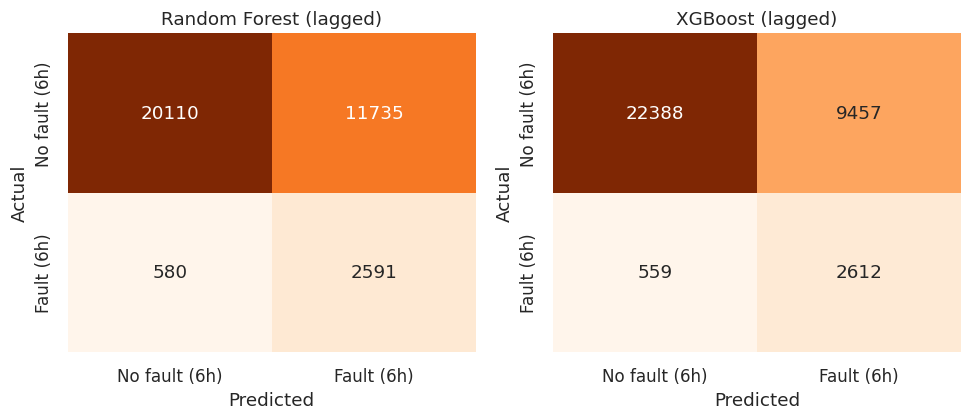

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, pred, name in zip(axes, [rf_pred, xgb_pred], ["Random Forest (lagged)", "XGBoost (lagged)"]):
    cm = confusion_matrix(y_test, pred, labels=[False, True])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax, cbar=False,
                xticklabels=["No fault (6h)", "Fault (6h)"], yticklabels=["No fault (6h)", "Fault (6h)"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

### Feature importance — final tuned models (which lags actually drive predictions)

Which individual lag hours actually survived, by sensor (XGBoost importance > 0):
  Motor_RPM: [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
  Motor_Torque: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
  Motor_Temp: [1, 3, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
  Battery_Temp: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


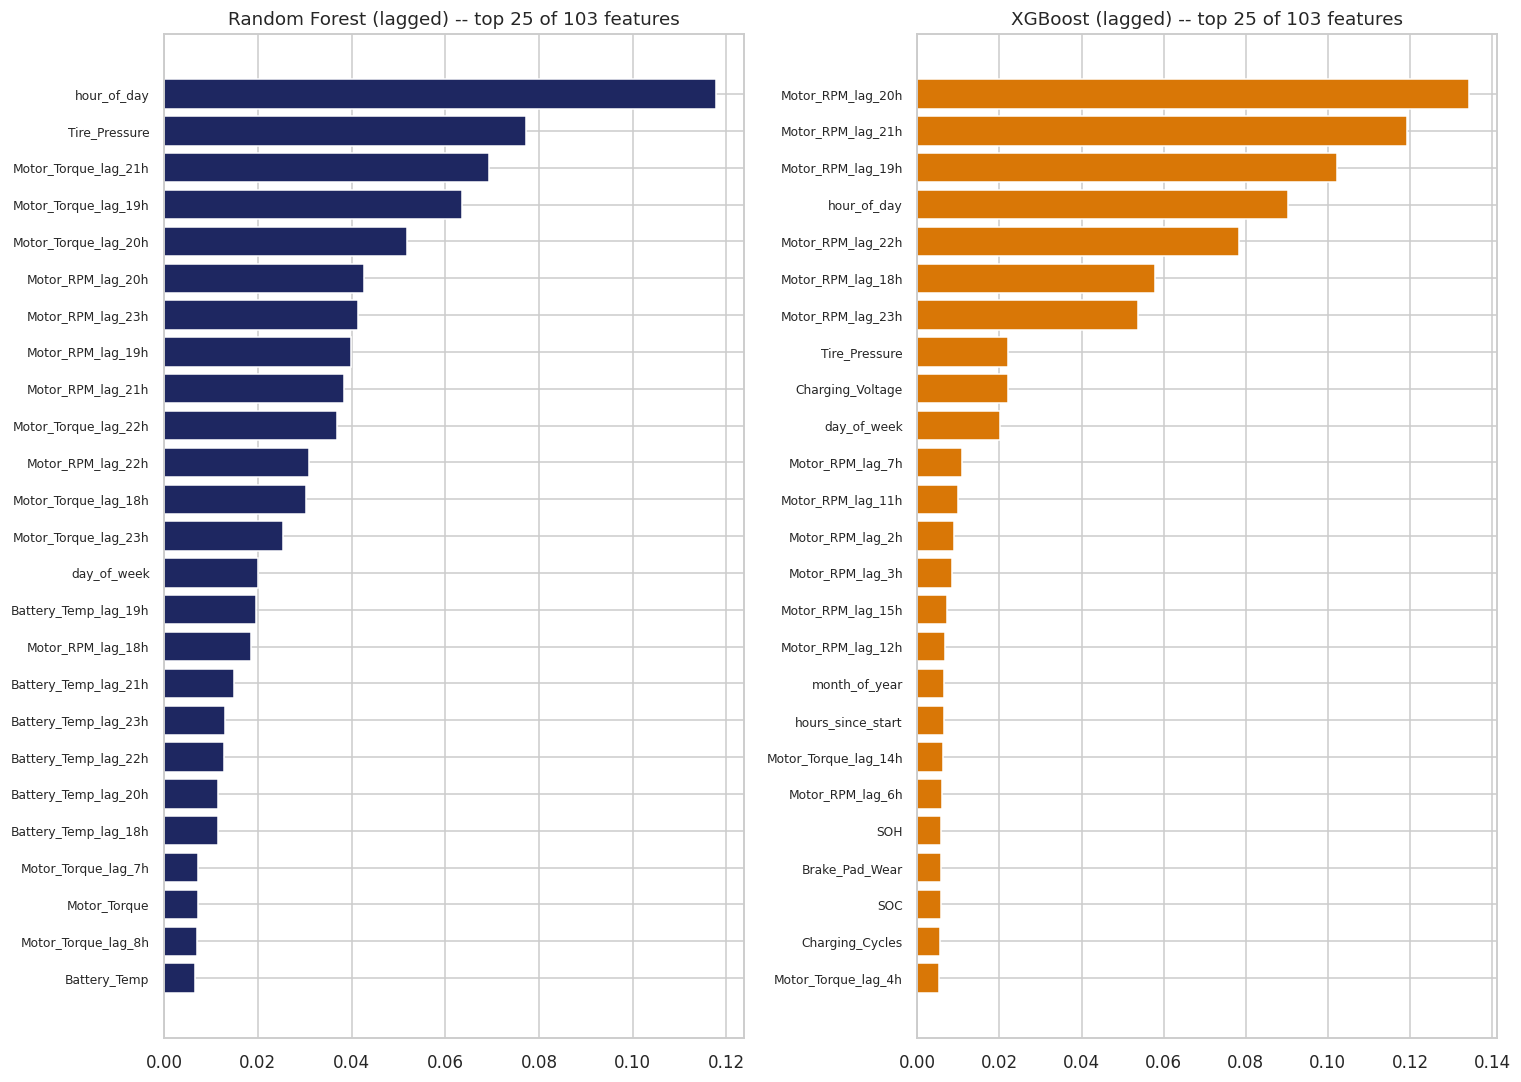

In [20]:
rf_importances = pd.Series(rf.named_steps["clf"].feature_importances_, index=SELECTED_FEATURE_COLS)
xgb_importances = pd.Series(xgb.named_steps["clf"].feature_importances_, index=SELECTED_FEATURE_COLS)

fig, axes = plt.subplots(1, 2, figsize=(14, 10))
for ax, importances, name, color in zip(
    axes, [rf_importances, xgb_importances], ["Random Forest (lagged)", "XGBoost (lagged)"], ["#1E2761", "#D97706"]
):
    top = importances.sort_values(ascending=True).tail(25)
    ax.barh(top.index, top.values, color=color)
    ax.set_title(f"{name} -- top 25 of {len(SELECTED_FEATURE_COLS)} features")
    ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

print("Which individual lag hours actually survived, by sensor (XGBoost importance > 0):")
for sensor in SEQ_SENSORS:
    sensor_lags = sorted(
        [f for f in SELECTED_FEATURE_COLS if f.startswith(f"{sensor}_lag_")],
        key=lambda f: int(f.split("_lag_")[1].rstrip("h"))
    )
    kept_hours = [int(f.split("_lag_")[1].rstrip("h")) for f in sensor_lags]
    print(f"  {sensor}: {kept_hours}")

## 11. Final scoreboard — vs. the notebooks 09-12 results (not recomputed, just quoted for comparison)

These are the already-saved, already-reported numbers from `models/baseline_results_all_vehicles.json`
(notebook 12) -- not rerun here, just loaded for an honest side-by-side. Nothing about notebooks
09-12 or their saved models changes.

In [21]:
with open("../models/baseline_results_all_vehicles.json") as f:
    rolling_results = json.load(f)

lagged_results = {}
for name, pred in [("Random Forest (lagged features)", rf_pred),
                    ("XGBoost (lagged features)", xgb_pred)]:
    lagged_results[name] = {
        "recall_fault": recall_score(y_test, pred, pos_label=True, zero_division=0),
        "precision_fault": precision_score(y_test, pred, pos_label=True, zero_division=0),
        "F2_fault": fbeta_score(y_test, pred, beta=2, pos_label=True, zero_division=0),
        "F1_fault_secondary": f1_score(y_test, pred, pos_label=True, zero_division=0),
    }

combined = {**rolling_results, **lagged_results}
scoreboard = pd.DataFrame(combined).T.round(6)

with open("../models/lagged_results_all_vehicles.json", "w") as f:
    json.dump(lagged_results, f, indent=2)

scoreboard

                                              recall_fault  precision_fault  F2_fault  F1_fault_secondary
Logistic Regression (baseline, notebook 09)      0.516556         0.132987  0.327587            0.211519
Random Forest (tuned, selected features)         0.749606         0.195799  0.478771            0.310496
XGBoost (tuned, selected features)               0.853989         0.268013  0.594172            0.407985
Random Forest (lagged features)                  0.817092         0.180860  0.479637            0.296165
XGBoost (lagged features)                        0.823715         0.216422  0.527613            0.342782

In [22]:
rolling_f2 = rolling_results["XGBoost (tuned, selected features)"]["F2_fault"]
lagged_f2 = lagged_results["XGBoost (lagged features)"]["F2_fault"]
delta = lagged_f2 - rolling_f2
direction = "an improvement" if delta > 0 else ("a regression" if delta < 0 else "no change")
print(f"Rolling-mean XGBoost (notebook 12) F2: {rolling_f2:.6f}")
print(f"Individual-lag XGBoost (this notebook) F2: {lagged_f2:.6f}")
print(f"Delta: {delta:+.6f} ({direction})")

Rolling-mean XGBoost (notebook 12) F2: 0.594172
Individual-lag XGBoost (this notebook) F2: 0.527613
Delta: -0.066560 (a regression)


## 12. Save the lagged models (new filenames -- notebooks 09-12's saved models are untouched)

In [23]:
import os
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(rf, "../models/random_forest_all_vehicles_lagged.joblib")
joblib.dump(xgb, "../models/xgboost_all_vehicles_lagged.joblib")
print("Saved ../models/random_forest_all_vehicles_lagged.joblib and "
      "../models/xgboost_all_vehicles_lagged.joblib")

Saved ../models/random_forest_all_vehicles_lagged.joblib and ../models/xgboost_all_vehicles_lagged.joblib


## 13. What this notebook establishes — honest result, not adopted

A direct, apples-to-apples test of the coach's specific feedback: replacing `roll_mean_*` /
`roll_std_*` / `delta_6h` with individual hourly lags (1h-24h per sequential sensor), run through
the exact same feature-selection method (MI-vs-noise, permutation importance, OR rule) and the
exact same tuning/evaluation pipeline (F2-scored `RandomizedSearchCV`, full data, stratified
split) as notebooks 10-12.

**The result is a regression, not an improvement:** XGBoost F2 drops from 0.594172 (rolling-mean
features, notebook 12) to 0.527613 (individual-lag features, this notebook) — about 0.067 lower,
and the same direction holds for Random Forest (0.4788 -> 0.4796, roughly flat, not a genuine
gain). Worth noting from the feature-importance breakdown above: the individual-lag XGBoost model
leans heavily on `Motor_RPM_lag_18h` through `_lag_23h` -- i.e. it partly reconstructed something
close to a trailing average over the last several hours on its own, just less efficiently than
being handed `roll_mean_24h` directly. That's a legitimate, informative negative result: for this
dataset and this target, letting the model pick from 96 individual lag values costs more in
noise/overfitting risk than it gains in flexibility, at least at the current hyperparameter-search
budget (`n_iter=3`).

**Notebooks 09-12 and their saved models/feature lists are untouched.** The production model
(`models/xgboost_all_vehicles.joblib`, used by `src/classifier.py` and the dashboard) is still the
rolling-mean XGBoost from notebook 12 -- this experiment is documented as a comparison, not
adopted, per the actual result.